In [22]:
##Continuing only with KS4, but can be adapted for LUPIN

import spikeinterface.full as si
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt

curated_analyzer_KS4 = si.load(r"C:\Users\moffi\Documents\UCL\SWC\OSSS\Hackathon notebooks\good_analyser_KS4.zarr")
spikes_KS4 = si.to_pynapple_tsgroup(curated_analyzer_KS4)
motion_data = nap.load_file(r"C:\Users\moffi\Documents\UCL\SWC\OSSS\Hackathon data\T1_1D_04032026_processed_pynapple.npz")


c:\Users\moffi\Documents\UCL\SWC\OSSS\Electrophysiology\course-ephys-osss\.venv\Lib\site-packages\spikeinterface\core\base.py:1159: FutureWarning: `recording_list` is deprecated and will be removed in 0.105.0. Please use `recording_list_or_dict` instead.
  extractor = extractor_class(**new_kwargs)


In [ ]:
#Check that spike file loaded
spikes_KS4.bombcell_labels

3      good
6      good
7      good
9      good
12     good
24     good
45     good
46     good
56     good
65     good
71     good
75     good
89     good
93     good
97     good
103    good
107    good
118    good
119    good
120    good
141    good
146    good
148    good
167    good
Name: bombcell_labels, dtype: object

In [16]:
#Check that movement file loaded

motion_data

Time (s)      head_x    head_y    head_direction
----------  --------  --------  ----------------
0.0          1362.89   1006.67          0.393964
0.04         1362.89   1006.67          0.393964
0.08         1362.71   1006.97          0.399165
0.12         1362.36   1008.57          0.451835
0.16         1362.35   1008.72          0.454561
0.2          1362.28   1010.33          0.411577
0.24         1362.22   1010.41          0.411386
...
165.12        nan       nan           nan
165.16        nan       nan           nan
165.2         nan       nan           nan
165.24        nan       nan           nan
165.28        nan       nan           nan
165.32        nan       nan           nan
165.36        nan       nan           nan
dtype: float64, shape: (4135, 3)

In [18]:
#Extract head position

position = motion_data[["head_x", "head_y"]]
position

Time (s)      head_x    head_y
----------  --------  --------
0.0          1362.89   1006.67
0.04         1362.89   1006.67
0.08         1362.71   1006.97
0.12         1362.36   1008.57
0.16         1362.35   1008.72
0.2          1362.28   1010.33
0.24         1362.22   1010.41
...
165.12        nan       nan
165.16        nan       nan
165.2         nan       nan
165.24        nan       nan
165.28        nan       nan
165.32        nan       nan
165.36        nan       nan
dtype: float64, shape: (4135, 2)

In [ ]:
#Generate spike time/head position comparison

positional_spikes = spikes_KS4.value_from(position)
positional_spikes[3]


Time (s)              head_x    head_y
------------------  --------  --------
0.9432666666666667   1364.78  1008.42
4.361033333333333    1354.43   918.5
6.0978               1390.01   938.558
6.101666666666667    1389.82   938.272
6.1071               1389.82   938.272
7.431466666666667    1264.36   920.498
7.534566666666667    1258.4    916.385
...
161.32716666666667   1550.35   525.064
162.1417              nan      nan
162.49523333333335    nan      nan
162.6136              nan      nan
162.93393333333333    nan      nan
163.06323333333333    nan      nan
163.74963333333332    nan      nan
dtype: float64, shape: (469, 2)

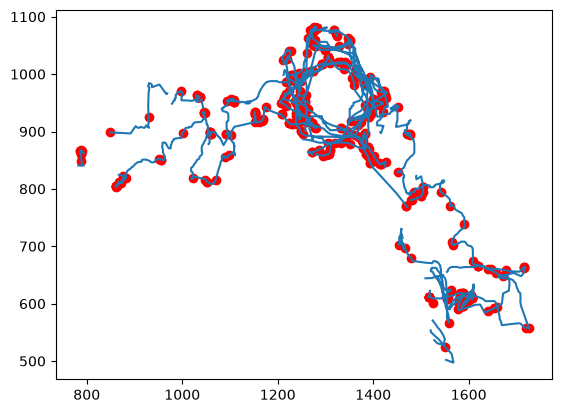

In [28]:
#Plot position trajectory with spikes overlayed for single neuron

plt.plot(position["head_x"], position["head_y"])
plt.scatter(positional_spikes[3]["head_x"], positional_spikes[3]["head_y"], color="red") #numbers in square brackets have to correspond to the neuron index

In [36]:
#Compute tuning curves for each neuron

tuning_curves = nap.compute_tuning_curves(
    data=spikes_KS4,
    features=position,
    bins=20,
    range=[(700,1800), (400,1200)],
)

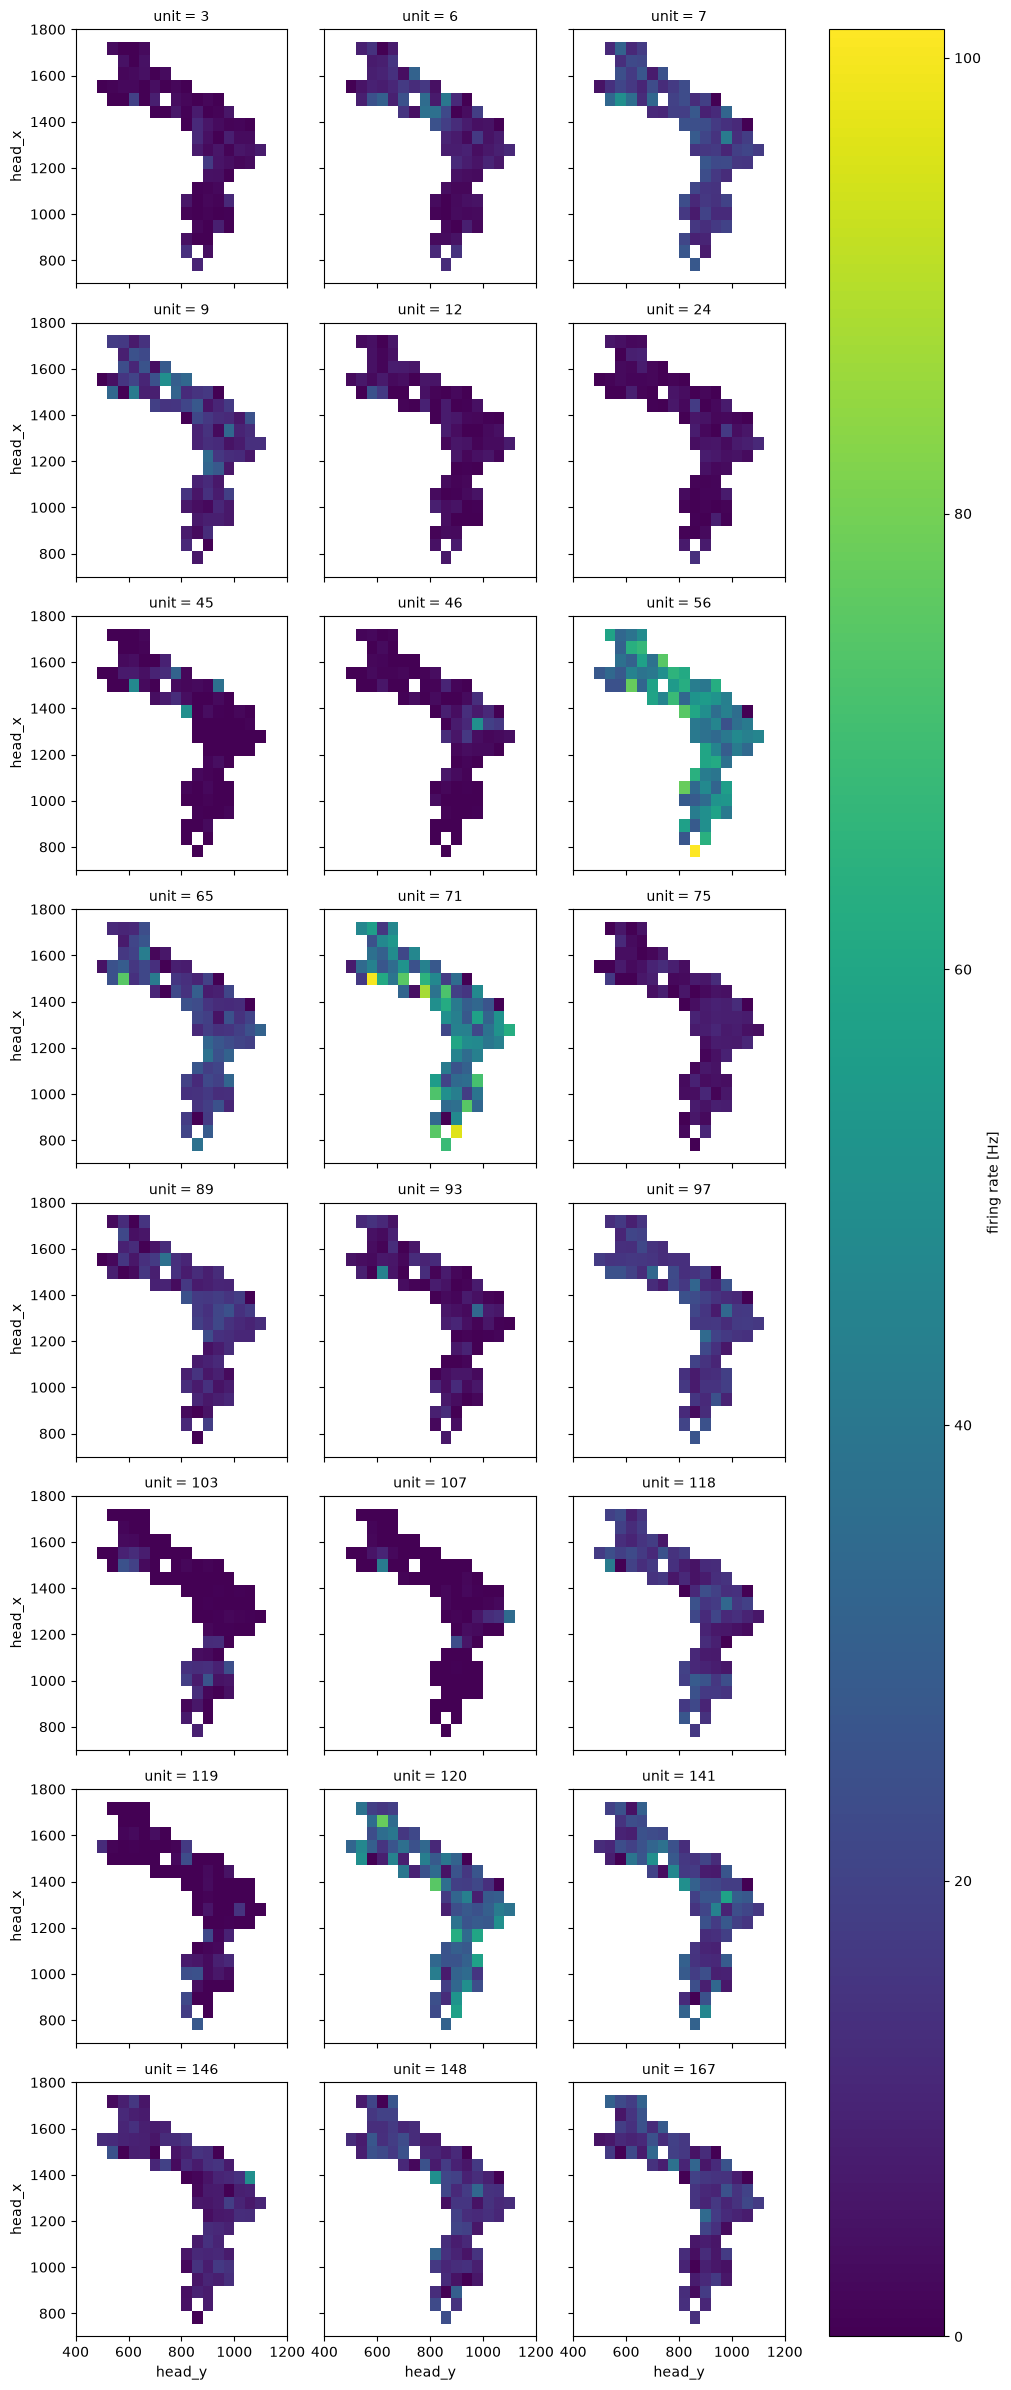

In [40]:
#Plot tuning curves

tuning_curves.name = "firing rate"
tuning_curves.attrs["unit"]="Hz"
tuning_curves.plot(col="unit", col_wrap=3)